In [2]:
import numpy as np
import matplotlib.pyplot as plt
import json

from scipy.integrate import solve_ivp

## Problem 1

In [3]:
# Lorenz-63 parameters
sigma = 10.0
rho = 28.0
beta = 8.0 / 3.0

def lorenz63(t, state):
    x, y, z = state

    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z

    return [dxdt, dydt, dzdt]

Run the sim for 1000 time units

In [4]:
dt = 0.1
t_final = 1000.0

t_eval = np.arange(0, t_final + dt, dt)

# Initial condition
x0 = [1.0, 1.0, 1.0]

sol = solve_ivp(
    lorenz63,
    [0, t_final],
    x0,
    t_eval=t_eval,
    rtol=1e-9,
    atol=1e-11
)

# Shape: (number of time steps, 3)
trajectory = sol.y.T

print("Trajectory shape:", trajectory.shape)

Trajectory shape: (10001, 3)


Plot the sim

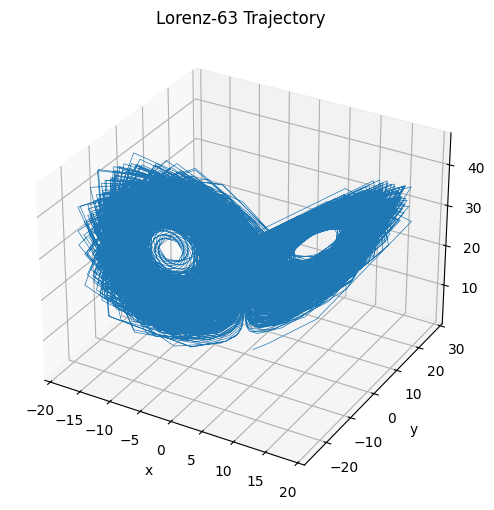

In [5]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot(
    trajectory[:, 0],
    trajectory[:, 1],
    trajectory[:, 2],
    linewidth=0.5
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Lorenz-63 Trajectory")

plt.show()

Remove the transient states. First 100 time units shaved off the front

In [6]:
t_transient = 100.0

mask = sol.t >= t_transient

trajectory_cov = trajectory[mask]

print("Samples used for covariance:", len(trajectory_cov))

Samples used for covariance: 9001


Compute the mean

In [7]:
mean_state = np.mean(trajectory_cov, axis=0)

print("Mean state:")
print(mean_state)

Mean state:
[-0.36401156 -0.36450444 23.51074591]


Compute the covariance

In [8]:
B = np.cov(trajectory_cov, rowvar=False)

print("Covariance matrix B:")
print(B)

Covariance matrix B:
[[62.57420522 62.58087667 -1.2768948 ]
 [62.58087667 81.31900091 -1.06205001]
 [-1.2768948  -1.06205001 75.02206781]]


Or do it with the sample cov function

In [10]:
N = trajectory_cov.shape[0]

B = np.zeros((trajectory_cov.shape[1], trajectory_cov.shape[1]))

for k in range(N):
    diff = trajectory_cov[k] - mean_state
    B += np.outer(diff, diff)

B = B / (N - 1)

print("Covariance matrix B:")
print(B)

Covariance matrix B:
[[62.57420522 62.58087667 -1.2768948 ]
 [62.58087667 81.31900091 -1.06205001]
 [-1.2768948  -1.06205001 75.02206781]]


Its the same matrix

Heatmap

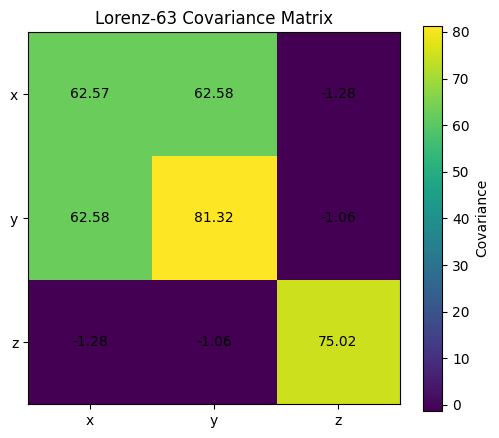

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(B)

ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])

ax.set_xticklabels(["x", "y", "z"])
ax.set_yticklabels(["x", "y", "z"])

ax.set_title("Lorenz-63 Covariance Matrix")

plt.colorbar(im, ax=ax, label="Covariance")

# Write numerical values inside cells
for i in range(B.shape[0]):
    for j in range(B.shape[1]):
        ax.text(j, i, f"{B[i, j]:.2f}",
                ha="center", va="center")

plt.show()

Save as json

In [11]:
import json

B_json = {
    "covariance_matrix": B.tolist()
}

with open("lorenz63_covariance.json", "w") as f:
    json.dump(B_json, f, indent=4)

print("Saved lorenz63_covariance.json")

Saved lorenz63_covariance.json


## Problem 3


In [ ]:
def lorenz63(t, state):
    x, y, z = state

    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z

    return [dxdt, dydt, dzdt]

def lorenz96(t, u, K=40, F=8.0, d=1.0):
    du = np.zeros(K)

    for k in range(K):
        km1 = (k - 1) % K
        km2 = (k - 2) % K
        kp1 = (k + 1) % K

        du[k] = (
            u[km1] * (u[kp1] - u[km2])
            - d * u[k]
            + F
        )

    return du

def lorenz96two(t, entries, K=40, F=8.0, d=1.0,
                gamma_j=0.05, ds=None, J=5):

    # If fast-variable damping values are not supplied
    if ds is None:
        ds = np.ones(J)

    # Split flattened state into u and v
    u = entries[:K]
    v = entries[K:].reshape((K, J))

    du = np.zeros(K)
    dv = np.zeros((K, J))

    for k in range(K):

        km1 = (k - 1) % K
        km2 = (k - 2) % K
        kp1 = (k + 1) % K

        # Coupling contribution from fast variables
        sum_term = 0.0

        for j in range(J):
            sum_term += gamma_j * v[k, j] * u[k]

            dv[k, j] = (
                -ds[j] * v[k, j]
                - gamma_j * u[k]**2
            )

        du[k] = (
            u[km1] * (u[kp1] - u[km2])
            + sum_term
            - d * u[k]
            + F
        )

    return np.concatenate((du, dv.flatten()))

#### Lorenz-63

In [ ]:
def threeDeeVar():
    return